# Feature Engineering with Weather Data: Wind Speed Forecasting


The base lab uses the [Jena Climate Dataset](https://www.bgc-jena.mpg.de/wetter/) to build a preprocessing pipeline targeting **temperature (`T (degC)`)** prediction. Here, the target has been changed to **wind speed (`wv (m/s)`)**, requiring a different feature selection strategy, a different normalization approach, and a different windowing configuration.

## Imports

In [5]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

print(f'TensorFlow : {tf.__version__}')
print(f'NumPy      : {np.__version__}')
print(f'pandas     : {pd.__version__}')

TensorFlow : 2.21.0
NumPy      : 2.4.4
pandas     : 3.0.2


## Download and Load the Data

In [6]:
# Download the Jena climate dataset
url = 'https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip'
path = tf.keras.utils.get_file('jena_climate_2009_2016.csv.zip', origin=url, extract=True)

# get_file with extract=True may return either the zip path or the extracted dir —
# walk up to the cache dir and find the CSV directly
csv_path = path.replace('.zip', '')
if os.path.isdir(csv_path):
    # extracted into a folder; find the CSV inside it
    matches = [os.path.join(csv_path, f) for f in os.listdir(csv_path) if f.endswith('.csv')]
    csv_path = matches[0]
elif not os.path.isfile(csv_path):
    # fallback: search the keras cache dir
    cache_dir = os.path.dirname(path)
    matches = [os.path.join(cache_dir, f) for f in os.listdir(cache_dir) if f.endswith('.csv')]
    csv_path = matches[0]

print(f'CSV path: {csv_path}')
df = pd.read_csv(csv_path)
print(f'Shape: {df.shape}')
df.tail()

CSV path: /Users/rishis/.keras/datasets/jena_climate_2009_2016_extracted/jena_climate_2009_2016.csv
Shape: (420551, 15)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
420546,31.12.2016 23:20:00,1000.07,-4.05,269.10,-8.13,73.10,4.52,3.30,1.22,2.06,3.30,1292.98,0.67,1.52,240.0
420547,31.12.2016 23:30:00,999.93,-3.35,269.81,-8.06,69.71,4.77,3.32,1.44,2.07,3.32,1289.44,1.14,1.92,234.3
420548,31.12.2016 23:40:00,999.82,-3.16,270.01,-8.21,67.91,4.84,3.28,1.55,2.05,3.28,1288.39,1.08,2.00,215.2
420549,31.12.2016 23:50:00,999.81,-4.23,268.94,-8.53,71.80,4.46,3.20,1.26,1.99,3.20,1293.56,1.49,2.16,225.8
420550,01.01.2017 00:00:00,999.82,-4.82,268.36,-8.42,75.70,4.27,3.23,1.04,2.01,3.23,1296.38,1.23,1.96,184.9


Observations are recorded every 10 minutes — 6 per hour, 144 per day.

## Inspect the Data

In [7]:
df.describe()

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
count,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000
mean,989.212776,9.450147,283.492743,4.955854,76.008259,13.576251,9.533756,4.042412,6.022408,9.640223,1216.062748,1.702224,3.056555,174.743738
std,8.358481,8.423365,8.504471,6.730674,16.476175,7.739020,4.184164,4.896851,2.656139,4.235395,39.975208,65.446714,69.016932,86.681693
min,913.600000,-23.010000,250.600000,-25.010000,12.950000,0.950000,0.790000,0.000000,0.500000,0.800000,1059.450000,-9999.000000,-9999.000000,0.000000
25%,984.200000,3.360000,277.430000,0.240000,65.210000,7.780000,6.210000,0.870000,3.920000,6.290000,1187.490000,0.990000,1.760000,124.900000
50%,989.580000,9.420000,283.470000,5.220000,79.300000,11.820000,8.860000,2.190000,5.590000,8.960000,1213.790000,1.760000,2.960000,198.100000
75%,994.720000,15.470000,289.530000,10.070000,89.400000,17.600000,12.350000,5.300000,7.800000,12.490000,1242.770000,2.860000,4.740000,234.100000
max,1015.350000,37.280000,311.340000,23.110000,100.000000,63.770000,28.320000,46.010000,18.130000,28.820000,1393.540000,28.490000,23.500000,360.000000


### Wind Speed Distribution vs Temperature

Wind speed is right-skewed and bounded at zero. Temperature is roughly symmetric. This motivates **z-score normalization** over min-max for wind: high-wind outliers would compress the useful range under min-max scaling.

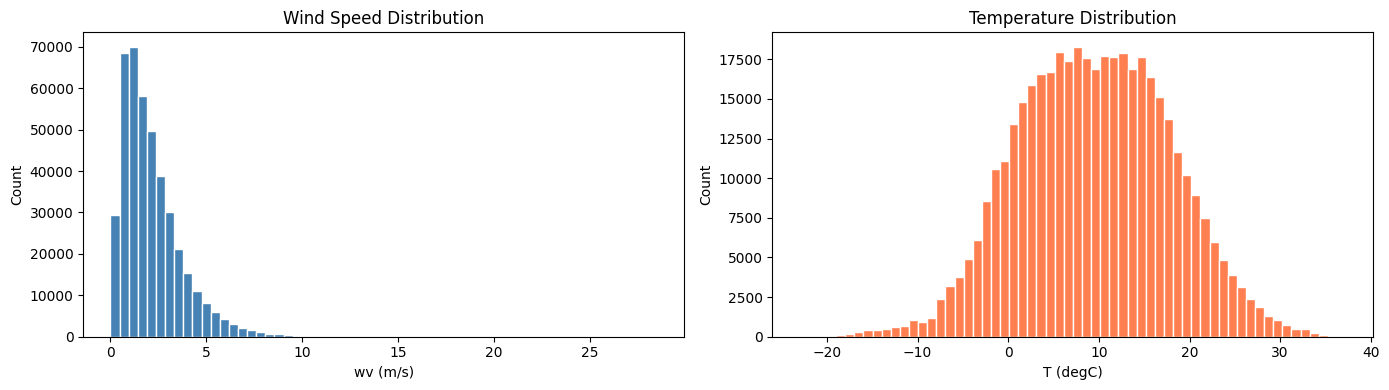

Wind speed skewness : 1.495
Temperature skewness: -0.019


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

wv_clean = df['wv (m/s)'].replace(-9999.0, np.nan).dropna()

axes[0].hist(wv_clean, bins=60, color='steelblue', edgecolor='white')
axes[0].set_title('Wind Speed Distribution')
axes[0].set_xlabel('wv (m/s)')
axes[0].set_ylabel('Count')

axes[1].hist(df['T (degC)'], bins=60, color='coral', edgecolor='white')
axes[1].set_title('Temperature Distribution')
axes[1].set_xlabel('T (degC)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'Wind speed skewness : {wv_clean.skew():.3f}')
print(f'Temperature skewness: {df["T (degC)"].skew():.3f}')

### Correlation Analysis — Target: Wind Speed

The base lab selects features based on correlation with **temperature**. Here we re-run the analysis against **wind speed** to motivate a different feature set.

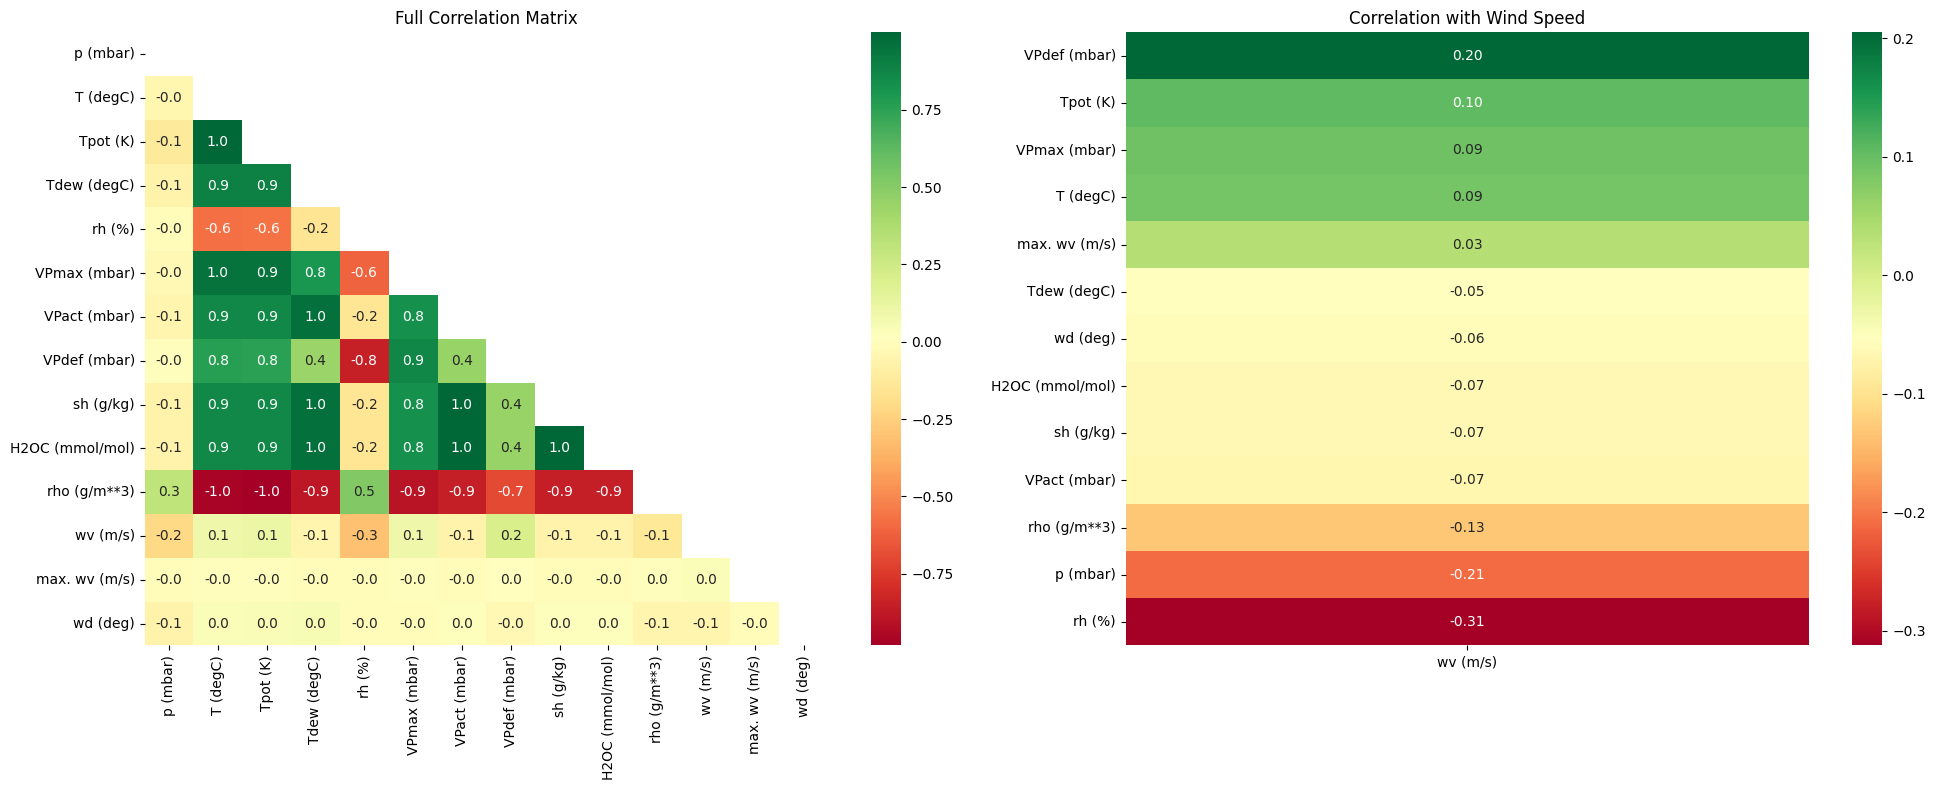

In [9]:
numeric_df = df.drop(columns=['Date Time'])
# Replace -9999 sentinel before computing correlations
numeric_df['wv (m/s)'] = numeric_df['wv (m/s)'].replace(-9999.0, 0.0)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

corr = numeric_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.1f', cmap='RdYlGn', ax=axes[0])
axes[0].set_title('Full Correlation Matrix')

wv_corr = corr[['wv (m/s)']].drop('wv (m/s)').sort_values('wv (m/s)', ascending=False)
sns.heatmap(wv_corr, annot=True, fmt='.2f', cmap='RdYlGn', ax=axes[1])
axes[1].set_title('Correlation with Wind Speed')

plt.tight_layout()
plt.show()

### Feature Selection

Based on the correlation analysis against wind speed:

- `max. wv (m/s)` — direct proxy for target, would leak information → **drop**
- `VPmax`, `VPact`, `sh (g/kg)`, `H2OC` — vapor pressure cluster, strongly correlated with each other but weakly with wind speed → **drop**
- `Tpot (K)` — near-linear function of `T (degC)` → **drop**
- `Tdew (degC)` — redundant with `rh (%)` → **drop**

Retained: `p (mbar)`, `T (degC)`, `rh (%)`, `VPdef (mbar)`, `rho (g/m**3)`, `wv (m/s)`, `wd (deg)` (last two become wind vector components).

In [10]:
FEATURES_TO_REMOVE = [
    'Tpot (K)',
    'Tdew (degC)',
    'VPact (mbar)',
    'VPmax (mbar)',
    'sh (g/kg)',
    'H2OC (mmol/mol)',
    'max. wv (m/s)',
]

print(f'Dropping {len(FEATURES_TO_REMOVE)} features: {FEATURES_TO_REMOVE}')

Dropping 7 features: ['Tpot (K)', 'Tdew (degC)', 'VPact (mbar)', 'VPmax (mbar)', 'sh (g/kg)', 'H2OC (mmol/mol)', 'max. wv (m/s)']


## Preprocessing

The base lab uses `tf.Transform` + Apache Beam for preprocessing. Here we replicate the same steps with **pandas** (cleaning, feature engineering) and **scikit-learn** (`StandardScaler`). The scaler is fit **only on the training split** and applied to both splits — the same guarantee tf.Transform provides.

Steps:
1. Fix `-9999.0` wind speed sentinel values
2. Convert datetime string → Unix timestamp
3. Drop redundant features
4. Wind vectorization: `(wv, wd)` → `(Wx, Wy)` 
5. Temporal periodicity: timestamp → `(Day sin/cos, Year sin/cos)`
6. Z-score normalization via `StandardScaler` fit on train split only

In [11]:
def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # --- 1. Fix wind speed sentinel ---
    df['wv (m/s)'] = df['wv (m/s)'].replace(-9999.0, 0.0)

    # --- 2. Convert datetime to Unix timestamp ---
    df['timestamp'] = df['Date Time'].apply(
        lambda s: datetime.strptime(s, '%d.%m.%Y %H:%M:%S').timestamp()
    )

    # --- 3. Drop redundant features ---
    df = df.drop(columns=FEATURES_TO_REMOVE + ['Date Time'])

    # --- 4. Wind vectorization ---
    wd_rad = df['wd (deg)'] * math.pi / 180.0
    df['Wx'] = df['wv (m/s)'] * np.cos(wd_rad)
    df['Wy'] = df['wv (m/s)'] * np.sin(wd_rad)
    # Keep wv (m/s) as the prediction target; drop raw direction
    df = df.drop(columns=['wd (deg)'])

    # --- 5. Temporal periodicity signals ---
    day  = 24 * 60 * 60
    year = 365.2425 * day
    ts   = df['timestamp']
    df['Day sin']  = np.sin(ts * (2 * math.pi / day))
    df['Day cos']  = np.cos(ts * (2 * math.pi / day))
    df['Year sin'] = np.sin(ts * (2 * math.pi / year))
    df['Year cos'] = np.cos(ts * (2 * math.pi / year))
    df = df.drop(columns=['timestamp'])

    return df

df_processed = preprocess(df)
print('Features after preprocessing:', list(df_processed.columns))
df_processed.head()

Features after preprocessing: ['p (mbar)', 'T (degC)', 'rh (%)', 'VPdef (mbar)', 'rho (g/m**3)', 'wv (m/s)', 'Wx', 'Wy', 'Day sin', 'Day cos', 'Year sin', 'Year cos']


,p (mbar),T (degC),rh (%),VPdef (mbar),rho (g/m**3),wv (m/s),Wx,Wy,Day sin,Day cos,Year sin,Year cos
0,996.52,-8.02,93.3,0.22,1307.75,1.03,-0.911955,0.478787,0.976296,0.216440,0.013036,0.999915
1,996.57,-8.41,93.4,0.21,1309.80,0.72,-0.518797,0.499249,0.984808,0.173648,0.013155,0.999913
2,996.53,-8.51,93.9,0.20,1310.24,0.19,-0.187962,0.027756,0.991445,0.130526,0.013274,0.999912
3,996.51,-8.31,94.2,0.19,1309.19,0.34,-0.323359,-0.105066,0.996195,0.087156,0.013394,0.999910
4,996.51,-8.27,94.1,0.19,1309.00,0.32,-0.264351,-0.180328,0.999048,0.043619,0.013513,0.999909


### Train / Test Split

Same split point as the base lab: first 300,000 observations for training, the remainder for test. The split is chronological — no shuffling.

In [12]:
TRAIN_SPLIT = 300000

train_df = df_processed.iloc[:TRAIN_SPLIT]
test_df  = df_processed.iloc[TRAIN_SPLIT:]

print(f'Train rows: {len(train_df):,}')
print(f'Test rows : {len(test_df):,}')

Train rows: 300,000
Test rows : 120,551


### Z-Score Normalization

Fit `StandardScaler` on the training split only, then apply to both. This mirrors what `tft.scale_to_z_score` does — computing mean/variance statistics from training data and applying them consistently at transform time.

In [13]:
# Columns to normalize — all except the periodic sin/cos signals which are already in [-1, 1]
COLS_TO_SCALE = ['p (mbar)', 'T (degC)', 'rh (%)', 'VPdef (mbar)', 'rho (g/m**3)',
                 'wv (m/s)', 'Wx', 'Wy']

scaler = StandardScaler()
scaler.fit(train_df[COLS_TO_SCALE])  # fit on train only

train_scaled = train_df.copy()
test_scaled  = test_df.copy()

train_scaled[COLS_TO_SCALE] = scaler.transform(train_df[COLS_TO_SCALE])
test_scaled[COLS_TO_SCALE]  = scaler.transform(test_df[COLS_TO_SCALE])

print('Scaler means (train):')
for col, mean, std in zip(COLS_TO_SCALE, scaler.mean_, scaler.scale_):
    print(f'  {col:20s}  mean={mean:8.3f}  std={std:.3f}')

train_scaled.head()

Scaler means (train):
  p (mbar)              mean= 988.651  std=8.236
  T (degC)              mean=   9.233  std=8.637
  rh (%)                mean=  75.931  std=16.547
  VPdef (mbar)          mean=   4.011  std=4.806
  rho (g/m**3)          mean=1216.406  std=40.868
  wv (m/s)              mean=   2.150  std=1.528
  Wx                    mean=  -0.592  std=2.007
  Wy                    mean=  -0.397  std=1.556


,p (mbar),T (degC),rh (%),VPdef (mbar),rho (g/m**3),wv (m/s),Wx,Wy,Day sin,Day cos,Year sin,Year cos
0,0.955474,-1.997663,1.049656,-0.788749,2.235079,-0.733305,-0.159204,0.562416,0.976296,0.216440,0.013036,0.999915
1,0.961545,-2.042819,1.055699,-0.790830,2.285240,-0.936198,0.036695,0.575562,0.984808,0.173648,0.013155,0.999913
2,0.956688,-2.054397,1.085916,-0.792911,2.296006,-1.283081,0.201541,0.272641,0.991445,0.130526,0.013274,0.999912
3,0.954259,-2.031241,1.104045,-0.794992,2.270314,-1.184907,0.134076,0.187307,0.996195,0.087156,0.013394,0.999910
4,0.954259,-2.026609,1.098002,-0.794992,2.265665,-1.197996,0.163478,0.138953,0.999048,0.043619,0.013513,0.999909


## Prepare Windowed tf.data Datasets

Window configuration (changed from base lab):

- **History**: 72 hourly steps = 3 days (stride=6 over 10-min data)
- **Horizon**: 6 hours ahead
- **Label**: `wv (m/s)` (z-score standardized wind speed)
- **Batch**: 48

In [14]:
LABEL_KEY             = 'wv (m/s)'
OBSERVATIONS_PER_HOUR = 6      # 10-min data
HISTORY_SIZE          = 72     # 3 days of hourly observations
FUTURE_TARGET         = 6      # predict 6 hours ahead
BATCH_SIZE            = 48
SHIFT                 = 1

LABEL_IDX = list(train_scaled.columns).index(LABEL_KEY)
NUM_FEATURES = len(train_scaled.columns)
print(f'Label column : "{LABEL_KEY}" at index {LABEL_IDX}')
print(f'Total features: {NUM_FEATURES}')
print(f'Columns: {list(train_scaled.columns)}')

Label column : "wv (m/s)" at index 5
Total features: 12
Columns: ['p (mbar)', 'T (degC)', 'rh (%)', 'VPdef (mbar)', 'rho (g/m**3)', 'wv (m/s)', 'Wx', 'Wy', 'Day sin', 'Day cos', 'Year sin', 'Year cos']


In [15]:
def make_dataset(data: pd.DataFrame) -> tf.data.Dataset:
    '''
    Builds a windowed tf.data.Dataset from a scaled DataFrame.

    Steps:
      1. Convert DataFrame to a tf.data.Dataset of row tensors
      2. Window into (HISTORY_SIZE + FUTURE_TARGET) length sequences
         with hourly stride (OBSERVATIONS_PER_HOUR)
      3. Split each window into (features, target) tuple
      4. Batch

    Args:
        data: Scaled DataFrame with all features.

    Returns:
        Batched tf.data.Dataset yielding (features, target) tuples.
        features shape: (BATCH_SIZE, HISTORY_SIZE, NUM_FEATURES)
        target shape  : (BATCH_SIZE, 1)
    '''
    arr = data.values.astype(np.float32)
    ds  = tf.data.Dataset.from_tensor_slices(arr)

    ds = ds.window(
        size          = HISTORY_SIZE + FUTURE_TARGET,
        shift         = SHIFT,
        stride        = OBSERVATIONS_PER_HOUR,
        drop_remainder= True,
    )
    ds = ds.flat_map(lambda w: w.batch(HISTORY_SIZE + FUTURE_TARGET))

    def split_window(window):
        features = window[:HISTORY_SIZE]                  # (72, NUM_FEATURES)
        target   = window[-1:, LABEL_IDX:LABEL_IDX + 1]  # (1, 1) → wind speed at horizon
        target   = tf.squeeze(target, axis=0)             # (1,)
        return features, target

    ds = ds.map(split_window)
    ds = ds.batch(BATCH_SIZE)
    return ds


train_dataset = make_dataset(train_scaled)
test_dataset  = make_dataset(test_scaled)

print('Datasets created.')

Datasets created.


## Preview Dataset Shapes and Values

In [16]:
print('=== TRAIN DATASET ===')
for features, target in train_dataset.take(1):
    print(f'features shape : {features.shape}')
    print(f'target shape   : {target.shape}')
    print(f'Expected       : ({BATCH_SIZE}, {HISTORY_SIZE}, {NUM_FEATURES}) features, ({BATCH_SIZE}, 1) target')
    print()
    print('First timestep of first example:')
    for val, name in zip(features[0][0].numpy(), train_scaled.columns):
        print(f'  {name:20s}: {val:.6f}')
    print(f'\n  TARGET WIND SPEED (z-score): {target[0][0]:.6f}')

=== TRAIN DATASET ===
features shape : (48, 72, 12)
target shape   : (48, 1)
Expected       : (48, 72, 12) features, (48, 1) target

First timestep of first example:
  p (mbar)            : 0.955474
  T (degC)            : -1.997663
  rh (%)              : 1.049656
  VPdef (mbar)        : -0.788749
  rho (g/m**3)        : 2.235079
  wv (m/s)            : -0.733305
  Wx                  : -0.159204
  Wy                  : 0.562416
  Day sin             : 0.976296
  Day cos             : 0.216440
  Year sin            : 0.013036
  Year cos            : 0.999915

  TARGET WIND SPEED (z-score): -0.595861


In [17]:
print('=== TEST DATASET ===')
for features, target in test_dataset.take(1):
    print(f'features shape : {features.shape}')
    print(f'target shape   : {target.shape}')
    print()
    print('First timestep of first example:')
    for val, name in zip(features[0][0].numpy(), test_scaled.columns):
        print(f'  {name:20s}: {val:.6f}')
    print(f'\n  TARGET WIND SPEED (z-score): {target[0][0]:.6f}')

=== TEST DATASET ===
features shape : (48, 72, 12)
target shape   : (48, 1)

First timestep of first example:
  p (mbar)            : 0.547485
  T (degC)            : 0.642228
  rh (%)              : 1.382038
  VPdef (mbar)        : -0.792911
  rho (g/m**3)        : -0.549222
  wv (m/s)            : 0.222257
  Wx                  : 1.409757
  Wy                  : 0.957600
  Day sin             : 0.996195
  Day cos             : -0.087156
  Year sin            : -0.950652
  Year cos            : -0.310258

  TARGET WIND SPEED (z-score): -1.034373


## Wrap Up

The preprocessing pipeline produces windowed `tf.data` datasets ready for sequence modeling:

- **Train**: `(48, 72, 12)` features → `(48, 1)` wind speed target
- **Test**: same shape

Key design decisions:

1. **Target = wind speed** — physically driven by pressure and density, requiring a different feature subset than temperature. The vapor pressure cluster dropped here was retained in the base lab.
2. **Z-score over min-max** — wind speed is right-skewed; `StandardScaler` fit on training split only mirrors `tft.scale_to_z_score` semantics without the dependency overhead.
3. **3-day window** — wind patterns are more locally stationary than temperature; a shorter lookback is sufficient and reduces sequence length by 40%.
4. **pandas + sklearn pipeline** — functionally equivalent to tf.Transform but compatible with Python 3.11+ and runnable on any Colab instance without version conflicts.